In [1]:
#3. 
#calculate NARCliM2.0 univ_exceed for 1951-2025 using 1951-2014 baseline 

#00. libraries and dask client 
import time
import xarray as xr
import numpy as np
import pandas as pd
import glob
import datetime
import time
import os
import gc

import matplotlib
import xarray, matplotlib.pyplot as plt
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()
import cartopy
import cartopy.crs as ccrs

import cartopy.feature as cfeature
from matplotlib.colors import LogNorm



import dask #parralelle processing 
import subprocess
import dask.array as da
from memory_profiler import profile
from filelock import FileLock
from dask.distributed import Client
from dask.utils import SerializableLock



from dask.diagnostics import ProgressBar

client = Client()
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 43655 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/43655/status,
Dashboard: /proxy/43655/status,Workers: 4
Total threads: 4,Total memory: 18.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34083,Workers: 0
Dashboard: /proxy/43655/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:42073,Total threads: 1
Dashboard: /proxy/36317/status,Memory: 4.50 GiB
Nanny: tcp://127.0.0.1:33075,


In [2]:
#5.0-2.0 define NARCLIM exceedance functions (modified version to deal with UKESM and NorESM data dimensions)

def load_dataset(
    var,
    domain,
    GCM,
    scenario,
    meG,
    provider,
    RCM,
    meR,
    tempRes,
    idir
):

    path_mask = (
        f"{IDIR}{var}_{domain}_{GCM}_{sc}_{meG}_"
        f"{provider}_{RCM}_{meR}_{tempRes}_*.nc"
    )

    files = glob.glob(path_mask)

    # --------------------------------------------------------
    # remove problematic CRS variables
    # --------------------------------------------------------

    def sanitize(ds):

        if "crs" in ds.dims:
            ds = ds.drop_dims("crs")

        if "crs" in ds.variables:
            ds = ds.drop_vars("crs")

        return ds

    # --------------------------------------------------------
    # open dataset
    # --------------------------------------------------------

    with dask.config.set(
        **{'array.slicing.split_large_chunks': False}
    ):

        ds = xr.open_mfdataset(
            files,
            preprocess=sanitize,
            combine='by_coords',
            chunks={'time': -1}
        )

    # --------------------------------------------------------
    # chunk ONLY data variables
    # --------------------------------------------------------

    for v in ds.data_vars:

        if {'time', 'lat', 'lon'}.issubset(ds[v].dims):

            ds[v] = ds[v].chunk({
                'time': -1,
                'lat': 'auto',
                'lon': 'auto'
            })

    return ds


def determine_univariate(
    data,
    out_prefix,
    thresh=0.99,
    ttype='q+',
    baseline_start='1951-01-01',
    baseline_end='2014-12-31', 
    period_start='1951-01-01',
    period_end='2025-12-31',
):

    import os

    # --------------------------------------------------------
    # select baseline period
    # --------------------------------------------------------

    # --------------------------------------------------------
    # select baseline years
    # works for 360_day / 365_day / standard calendars
    # --------------------------------------------------------
    
    baseline_start_year = int(baseline_start[:4])
    baseline_end_year = int(baseline_end[:4])
    
    data_baseline = data.where(
        (data.time.dt.year >= baseline_start_year) &
        (data.time.dt.year <= baseline_end_year),
        drop=True
    )

    period_start_year = int(period_start[:4])
    period_end_year = int(period_end[:4])
    
    data_sel = data.where(
        (data.time.dt.year >= period_start_year) &
        (data.time.dt.year <= period_end_year),
        drop=True
    )
    
    # --------------------------------------------------------
    # threshold from 1951-2014 only
    # --------------------------------------------------------

    if 'q' in ttype:

        threshold = data_baseline.quantile(
            thresh,
            dim='time',
            skipna=True
        )

    else:

        threshold = thresh

    # --------------------------------------------------------
    # exceedance ONLY for 1951-2014
    # --------------------------------------------------------

    if '+' in ttype:

        univ_exceed = xr.where(
            data_sel > threshold,
            1,
            0
        )

    else:

        univ_exceed = xr.where(
            data_sel < threshold,
            1,
            0
        )


    # ========================================================
    # OUTPUT FILES (NO HARDCODED YEARS)
    # ========================================================
    
    suffix = f"{period_start[:4]}_{period_end[:4]}"
    
    out_file = f"{out_prefix}_univ_exceed_{suffix}.nc"
    threshold_out_file = f"{out_prefix}_threshold_{suffix}.nc"
    # --------------------------------------------------------
    # remove existing files
    # --------------------------------------------------------

    for f in [out_file, threshold_out_file]:

        if os.path.exists(f):

            os.remove(f)

    # --------------------------------------------------------
    # save exceedance
    # --------------------------------------------------------

    with FileLock(f"{out_file}.lock"):

        univ_exceed.to_netcdf(
            out_file,
            mode='w'
        )

    # --------------------------------------------------------
    # save threshold
    # --------------------------------------------------------

    with FileLock(f"{threshold_out_file}.lock"):

        threshold.to_netcdf(
            threshold_out_file,
            mode='w'
        )

    print(f"Saved:\n{out_file}")

    print(f"Saved:\n{threshold_out_file}")



In [ ]:
#5.0-2.1 iteration --ACCESS 
GCMs = ['ACCESS-ESM1-5']  # Add more GCMs here
RCMs = ['NARCliM2-0-WRF412R3', 'NARCliM2-0-WRF412R5']
vars = ['tas','pr']

scenarios = ['historical', 'ssp370']


for var in vars:
    for GCM in GCMs:
        for RCM in RCMs:
            meG = 'r6i1p1f1'
            meR = 'v1-r1'
            domain = 'AUS-18'
            provider = 'NSW-Government'
            tempRes = 'day'
            IDIR = '/scratch/dt6/xw9650/tmp/regridded/'
            OUTDIR = '/scratch/dt6/xw9650/tmp/regridded_AGCD/exceedance_NARCliM/'
            
            # Load both scenarios
            datasets = []
            for sc in scenarios:
                ds = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)
                datasets.append(ds)

            # Combine historical and future
            data = xr.concat(datasets, dim='time').sortby('time')
   

            prefix = f"{OUTDIR}{var}_{GCM}_{RCM}_{sc}"
                
            #this is modified to accommodate 1951-2015 -combining historical and future 
            determine_univariate(data[var], prefix, thresh=0.99, ttype='q+', baseline_start='1951-01-01',baseline_end='2014-12-31', period_start='1951-01-01',period_end='2025-12-31')
    

In [3]:
#5.0-2.1 iteration --ACCESS 
GCMs = ['EC-Earth3-Veg']  # Add more GCMs here
RCMs = ['NARCliM2-0-WRF412R5']#, 'NARCliM2-0-WRF412R5']
vars = ['tas']#pr

scenarios = ['historical', 'ssp370']


for var in vars:
    for GCM in GCMs:
        for RCM in RCMs:
            meG = 'r1i1p1f1'
            meR = 'v1-r1'
            domain = 'AUS-18'
            provider = 'NSW-Government'
            tempRes = 'day'
            IDIR = '/scratch/dt6/xw9650/tmp/regridded/'
            OUTDIR = '/scratch/dt6/xw9650/tmp/regridded_AGCD/exceedance_NARCliM/'
            
            # Load both scenarios
            datasets = []
            for sc in scenarios:
                ds = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)
                datasets.append(ds)

            # Combine historical and future
            data = xr.concat(datasets, dim='time').sortby('time')
   
        
            prefix = f"{OUTDIR}{var}_{GCM}_{RCM}_{sc}"
                
            #this is modified to accommodate 1951-2015 -combining historical and future 
            determine_univariate(data[var], prefix, thresh=0.99, ttype='q+', baseline_start='1951-01-01',baseline_end='2014-12-31', period_start='1951-01-01',period_end='2025-12-31')
    

Saved:
/scratch/dt6/xw9650/tmp/regridded_AGCD/exceedance_NARCliM/tas_EC-Earth3-Veg_NARCliM2-0-WRF412R5_ssp370_univ_exceed_1951_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_AGCD/exceedance_NARCliM/tas_EC-Earth3-Veg_NARCliM2-0-WRF412R5_ssp370_threshold_1951_2025.nc


In [ ]:
#5.0-2.1 iteration --ACCESS 
GCMs = ['MPI-ESM1-2-HR']  # Add more GCMs here
RCMs = ['NARCliM2-0-WRF412R3', 'NARCliM2-0-WRF412R5']
vars = ['tas']#pr

scenarios = ['historical', 'ssp370']


for var in vars:
    for GCM in GCMs:
        for RCM in RCMs:
            meG = 'r1i1p1f1'
            meR = 'v1-r1'
            domain = 'AUS-18'
            provider = 'NSW-Government'
            tempRes = 'day'
            IDIR = '/scratch/dt6/xw9650/tmp/regridded/'
            OUTDIR = '/scratch/dt6/xw9650/tmp/regridded_AGCD/exceedance_NARCliM/'
            
            # Load both scenarios
            datasets = []
            for sc in scenarios:
                ds = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)
                datasets.append(ds)

            # Combine historical and future
            data = xr.concat(datasets, dim='time').sortby('time')
   
           
            prefix = f"{OUTDIR}{var}_{GCM}_{RCM}_{sc}"
                
            #this is modified to accommodate 1951-2015 -combining historical and future 
            determine_univariate(data[var], prefix, thresh=0.99, ttype='q+', baseline_start='1951-01-01',baseline_end='2014-12-31', period_start='1951-01-01',period_end='2025-12-31')
    

In [ ]:
#5.0-2.1 iteration --ACCESS 
GCMs = ['NorESM2-MM']  # Add more GCMs here
RCMs = ['NARCliM2-0-WRF412R3', 'NARCliM2-0-WRF412R5']
vars = ['tas']#pr

scenarios = ['historical', 'ssp370']


for var in vars:
    for GCM in GCMs:
        for RCM in RCMs:
            meG = 'r1i1p1f1'
            meR = 'v1-r1'
            domain = 'AUS-18'
            provider = 'NSW-Government'
            tempRes = 'day'
            IDIR = '/scratch/dt6/xw9650/tmp/regridded/'
            OUTDIR = '/scratch/dt6/xw9650/tmp/regridded_AGCD/exceedance_NARCliM/'
            
            # Load both scenarios
            datasets = []
            for sc in scenarios:
                ds = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)
                datasets.append(ds)

            # Combine historical and future
            data = xr.concat(datasets, dim='time').sortby('time')
   
           
            prefix = f"{OUTDIR}{var}_{GCM}_{RCM}_{sc}"
                
            #this is modified to accommodate 1951-2015 -combining historical and future 
            determine_univariate(data[var], prefix, thresh=0.99, ttype='q+', baseline_start='1951-01-01',baseline_end='2014-12-31', period_start='1951-01-01',period_end='2025-12-31')
    

In [ ]:
#5.0-2.1 iteration --ACCESS 
GCMs = ['UKESM1-0-LL']# Add more GCMs here
RCMs = ['NARCliM2-0-WRF412R3', 'NARCliM2-0-WRF412R5']
vars = ['tas']#pr

scenarios = ['historical', 'ssp370']


for var in vars:
    for GCM in GCMs:
        for RCM in RCMs:
            meG = 'r1i1p1f2'
            meR = 'v1-r1'
            domain = 'AUS-18'
            provider = 'NSW-Government'
            tempRes = 'day'
            IDIR = '/scratch/dt6/xw9650/tmp/regridded/'
            OUTDIR = '/scratch/dt6/xw9650/tmp/regridded_AGCD/exceedance_NARCliM/'
            
            # Load both scenarios
            datasets = []
            for sc in scenarios:
                ds = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)
                datasets.append(ds)

            # Combine historical and future
            data = xr.concat(datasets, dim='time').sortby('time')
   
           
            prefix = f"{OUTDIR}{var}_{GCM}_{RCM}_{sc}"
                
            #this is modified to accommodate 1951-2015 -combining historical and future 
            determine_univariate(data[var], prefix, thresh=0.99, ttype='q+', baseline_start='1951-01-01',baseline_end='2014-12-31', period_start='1951-01-01',period_end='2025-12-31')
    

In [25]:
# redesign 5.1--tas
# ============================================================
# COMPUTE ANNUAL EXCEEDANCE SUMMARIES
# DASK-OPTIMISED VERSION
# ============================================================

from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import regionmask

from dask import delayed, compute
from dask.distributed import Client

# ============================================================
# DASK CLIENT
# ============================================================

client = Client(
    n_workers=8,
    threads_per_worker=1,
    memory_limit="8GB"
)

print(client)

# ============================================================
# SETTINGS
# ============================================================

agcd_file = (
    "/scratch/dt6/xw9650/tmp/regridded_AGCD/"
    "tas_univ_exceed_1951_2025.nc"
)

model_template = (
    "/scratch/dt6/xw9650/tmp/regridded_AGCD/exceedance_NARCliM/"
    "tas_{gcm}_{rcm}_ssp370_univ_exceed_1951_2025.nc"
)

mask_shapefile = (
    "/scratch/dt6/xw9650/tmp/reference_data/"
    "NRM_clusters/NRM_clusters.shp"
)

output_dir = Path(
    "/scratch/dt6/xw9650/tmp/regridded_AGCD"
)

summary_dir = output_dir / "summaries"

output_dir.mkdir(exist_ok=True)

summary_dir.mkdir(exist_ok=True)

mask_nc = output_dir / "nrm_mask.nc"

gcms = [
    "ACCESS-ESM1-5",
    "EC-Earth3-Veg",
    "MPI-ESM1-2-HR",
    "NorESM2-MM",
    "UKESM1-0-LL"
]

rcms = [
    "NARCliM2-0-WRF412R3",
    "NARCliM2-0-WRF412R5"
]

# ============================================================
# CREATE REGION MASK ONCE
# ============================================================

def create_nrm_mask(
    sample_file,
    shapefile,
    out_file
):

    print("Creating NRM mask...")

    ds = xr.open_dataset(sample_file)

    gdf = (
        gpd.read_file(shapefile)
        .to_crs("EPSG:4326")
    )

    gdf = gdf[
        gdf.geometry.notnull()
    ]

    regions = regionmask.Regions(
        outlines=list(gdf.geometry),
        names=gdf["label"].tolist(),
        numbers=list(range(len(gdf)))
    )

    mask = regions.mask(
        ds.lon,
        ds.lat
    )

    mask.name = "nrm_mask"

    mask.to_netcdf(out_file)

    print(f"Saved mask:\n{out_file}")

# ============================================================
# CREATE MASK IF MISSING
# ============================================================

if not mask_nc.exists():

    create_nrm_mask(
        agcd_file,
        mask_shapefile,
        mask_nc
    )

# ============================================================
# LOAD MASK
# ============================================================

mask = xr.open_dataarray(mask_nc)

# ============================================================
# REGION NAMES
# ============================================================

gdf_regions = (
    gpd.read_file(mask_shapefile)
    .to_crs("EPSG:4326")
)

region_names = {
    i: name
    for i, name in enumerate(
        gdf_regions["label"].tolist()
    )
}

# ============================================================
# SUMMARY FUNCTION
# ============================================================

def summarise_annual_exceedance(
    nc_file,
    out_file,
    source_name
):

    print(f"\nProcessing:\n{nc_file}")

    ds = xr.open_dataset(
        nc_file,
        chunks={"time": 365}
    )

    # ========================================================
    # AUTO-DETECT VARIABLE
    # ========================================================

    var_name = list(ds.data_vars)[0]

    da = ds[var_name]

    # ========================================================
    # CONVERT BOOLEAN TO INTEGER
    # ========================================================

    if da.dtype == bool:

        da = da.astype("int16")

    # ========================================================
    # ANNUAL SUM
    # ========================================================

    annual = (
        da
        .resample(time="YE")
        .sum(dim="time")
    )

    # ========================================================
    # REGION IDS
    # ========================================================

    region_ids = np.unique(
        mask.values[
            np.isfinite(mask.values)
        ]
    ).astype(int)

    all_rows = []

    # ========================================================
    # LOOP REGIONS
    # ========================================================

    for region_id in region_ids:

        regional = (
            annual
            .where(mask == region_id)
            .mean(dim=["lat", "lon"])
        )

        regional = regional.compute()

        years = regional["time.year"].values

        values = regional.values

        rows = pd.DataFrame({
            "NRM": region_names[region_id],
            "year": years.astype(int),
            "annual_exceedance_days": values.astype(float),
            "Source": source_name
        })

        all_rows.append(rows)

    # ========================================================
    # CONCATENATE
    # ========================================================

    df = pd.concat(
        all_rows,
        ignore_index=True
    )

    # ========================================================
    # SAVE
    # ========================================================

    df.to_parquet(out_file)

    print(f"Saved:\n{out_file}")

    return out_file

# ============================================================
# CREATE TASKS
# ============================================================

tasks = []

# ============================================================
#AGCD TASK
# ============================================================

agcd_out = (
    summary_dir /
    "tas_AGCD_summary_1951_2025.parquet"
)

tasks.append(
    delayed(
        summarise_annual_exceedance
    )(
        agcd_file,
        agcd_out,
        "AGCD"
    )
)

# ============================================================
# MODEL TASKS
# ============================================================

for gcm, rcm in product(gcms, rcms):

    model_file = model_template.format(
        gcm=gcm,
        rcm=rcm
    )

    if not Path(model_file).exists():

        print(f"Missing:\n{model_file}")
        continue

    out_file = (
        summary_dir /
        f"tas_{gcm}_{rcm}_summary_1951_2025.parquet"
    )

    source_name = f"{gcm}_{rcm}"

    tasks.append(
        delayed(
            summarise_annual_exceedance
        )(
            model_file,
            out_file,
            source_name
        )
    )

# ============================================================
# RUN TASKS
# ============================================================

results = compute(*tasks)

print("\nFinished summaries:")

for r in results:
    print(r)

# ============================================================
# CLOSE CLIENT
# ============================================================

client.close()

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 41675 instead
  warnings.warn(


<Client: 'tcp://127.0.0.1:40451' processes=8 threads=8, memory=59.60 GiB>

Finished summaries:
/scratch/dt6/xw9650/tmp/regridded_AGCD/summaries/tas_summary_1951_2025.parquet
/scratch/dt6/xw9650/tmp/regridded_AGCD/summaries/tas_ACCESS-ESM1-5_NARCliM2-0-WRF412R3_summary_1951_2025.parquet
/scratch/dt6/xw9650/tmp/regridded_AGCD/summaries/tas_ACCESS-ESM1-5_NARCliM2-0-WRF412R5_summary_1951_2025.parquet
/scratch/dt6/xw9650/tmp/regridded_AGCD/summaries/tas_EC-Earth3-Veg_NARCliM2-0-WRF412R3_summary_1951_2025.parquet
/scratch/dt6/xw9650/tmp/regridded_AGCD/summaries/tas_EC-Earth3-Veg_NARCliM2-0-WRF412R5_summary_1951_2025.parquet
/scratch/dt6/xw9650/tmp/regridded_AGCD/summaries/tas_MPI-ESM1-2-HR_NARCliM2-0-WRF412R3_summary_1951_2025.parquet
/scratch/dt6/xw9650/tmp/regridded_AGCD/summaries/tas_MPI-ESM1-2-HR_NARCliM2-0-WRF412R5_summary_1951_2025.parquet
/scratch/dt6/xw9650/tmp/regridded_AGCD/summaries/tas_NorESM2-MM_NARCliM2-0-WRF412R3_summary_1951_2025.parquet
/scratch/dt6/xw9650/tmp/regridded_AGCD

In [7]:
# redesign 5.2 -create gridcell trends data -tas
# ============================================================
# COMPUTE GRIDCELL TRENDS FROM EXCEEDANCE DATA
# VECTORISED + DASK OPTIMISED
# ============================================================

from itertools import product
from pathlib import Path

import numpy as np
import xarray as xr
from dask import delayed, compute
from dask.distributed import Client
from scipy.stats import linregress

# ============================================================
# DASK CLIENT
# ============================================================

client = Client(
    n_workers=8,
    threads_per_worker=1,
    memory_limit="8GB"
)

print(client)

# ============================================================
# SETTINGS
# ============================================================

START_YEAR = 1951
END_YEAR = 2025

obs_file = (
    "/scratch/dt6/xw9650/tmp/regridded_AGCD/"
    "tas_univ_exceed_1951_2025.nc"
)

model_template = (
    "/scratch/dt6/xw9650/tmp/regridded_AGCD/exceedance_NARCliM/"
    "tas_{gcm}_{rcm}_ssp370_univ_exceed_1951_2025.nc"
)

output_dir = Path(
    "/scratch/dt6/xw9650/tmp/regridded_AGCD/trend_maps"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

gcms = [
    "ACCESS-ESM1-5",
    "EC-Earth3-Veg",
    "MPI-ESM1-2-HR",
    "NorESM2-MM",
    "UKESM1-0-LL"
]

rcms = [
    "NARCliM2-0-WRF412R3",
    "NARCliM2-0-WRF412R5"
]

# ============================================================
# TREND FUNCTION
# ============================================================

def compute_gridcell_trend(nc_file, out_file):

    print(f"\nProcessing:\n{nc_file}")

    # --------------------------------------------------------
    # OPEN
    # --------------------------------------------------------

    ds = xr.open_dataset(
        nc_file,
        chunks={"lat": 10, "lon": 10}
    )

    var_name = list(ds.data_vars)[0]
    da = ds[var_name]

    # ============================================================
    # FILTER TIME (CRITICAL FIX)
    # ============================================================

    da = da.where(
        (da.time.dt.year >= START_YEAR) &
        (da.time.dt.year <= END_YEAR),
        drop=True
    )

    # --------------------------------------------------------
    # BOOLEAN -> INTEGER
    # --------------------------------------------------------

    if da.dtype == bool:
        da = da.astype("int16")

    # --------------------------------------------------------
    # ANNUAL EXCEEDANCE DAYS
    # --------------------------------------------------------

    annual = (
        da
        .resample(time="YE")
        .sum(dim="time")
    )

    # --------------------------------------------------------
    # YEAR COORDINATE
    # --------------------------------------------------------

    annual = annual.assign_coords(
        year=("time", annual["time.year"].values)
    )

    # --------------------------------------------------------
    # TREND (PIXEL-WISE)
    # --------------------------------------------------------

    trend_ds = annual.polyfit(
        dim="year",
        deg=1,
        skipna=True
    )

    slope = trend_ds.polyfit_coefficients.sel(degree=1)
    slope.name = "trend"

    slope.attrs["description"] = (
        f"Trend in annual exceedance days "
        f"(days/year), {START_YEAR}-{END_YEAR}"
    )

    # --------------------------------------------------------
    # SAVE
    # --------------------------------------------------------

    slope.to_netcdf(out_file)

    print(f"Saved:\n{out_file}")

    return out_file
# ============================================================
# TREND FUNCTION (UPDATED to include p-value)
# ============================================================

def compute_gridcell_trend_with_pvalue(nc_file, out_file):

    print(f"\nProcessing:\n{nc_file}")

    ds = xr.open_dataset(
        nc_file,
        chunks={"lat": 10, "lon": 10}
    )

    var_name = list(ds.data_vars)[0]
    da = ds[var_name]

    # --------------------------------------------------------
    # TIME FILTER
    # --------------------------------------------------------

    da = da.where(
        (da.time.dt.year >= START_YEAR) &
        (da.time.dt.year <= END_YEAR),
        drop=True
    )

    if da.dtype == bool:
        da = da.astype("int16")

    # --------------------------------------------------------
    # ANNUAL SUM
    # --------------------------------------------------------

    annual = da.resample(time="YE").sum(dim="time")

    years = annual["time.year"].values

    # ========================================================
    # MINIMAL CHANGE: ADD SIGNIFICANCE VIA LINREGRESS
    # ========================================================

    def _trend(y):

        if np.all(np.isnan(y)):
            return np.array([np.nan, np.nan])

        slope, intercept, r, p, stderr = linregress(years, y)

        return np.array([slope, p])   # slope + p-value

    result = xr.apply_ufunc(
        _trend,
        annual,
        input_core_dims=[["time"]],
        output_core_dims=[["stat"]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
        output_sizes={"stat": 2}
    )

    slope = result.isel(stat=0)
    pval = result.isel(stat=1)

    slope.name = "trend"
    pval.name = "p_value"

    slope.attrs["description"] = (
        f"Trend in annual exceedance (days/year), "
        f"{START_YEAR}-{END_YEAR}"
    )

    pval.attrs["description"] = "p-value of linear trend"

    # --------------------------------------------------------
    # SAVE (NOW DATASET INSTEAD OF SINGLE VARIABLE)
    # --------------------------------------------------------

    out_ds = xr.Dataset({
        "trend": slope,
        "p_value": pval
    })

    out_ds.to_netcdf(out_file)

    print(f"Saved:\n{out_file}")

    return out_file

# ============================================================
# TASKS
# ============================================================

tasks = []


# ------------------------------------------------------------
# MODELS
# ------------------------------------------------------------

for gcm, rcm in product(gcms, rcms):

    model_file = model_template.format(
        gcm=gcm,
        rcm=rcm
    )

    if not Path(model_file).exists():
        print(f"Missing:\n{model_file}")
        continue

    out_file = (
        output_dir /
        f"tas_{gcm}_{rcm}_trend_1951_2025.nc"
    )

    tasks.append(
        delayed(compute_gridcell_trend)(
            model_file,
            out_file
        )
    )

# ============================================================
# RUN
# ============================================================

results = compute(*tasks)

print("\nFinished trend calculations:")
print(results)

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 35269 instead
  warnings.warn(


<Client: 'tcp://127.0.0.1:33893' processes=8 threads=8, memory=59.60 GiB>

Finished trend calculations:
(PosixPath('/scratch/dt6/xw9650/tmp/regridded_AGCD/trend_maps/tas_ACCESS-ESM1-5_NARCliM2-0-WRF412R3_trend_1951_2025.nc'), PosixPath('/scratch/dt6/xw9650/tmp/regridded_AGCD/trend_maps/tas_ACCESS-ESM1-5_NARCliM2-0-WRF412R5_trend_1951_2025.nc'), PosixPath('/scratch/dt6/xw9650/tmp/regridded_AGCD/trend_maps/tas_EC-Earth3-Veg_NARCliM2-0-WRF412R3_trend_1951_2025.nc'), PosixPath('/scratch/dt6/xw9650/tmp/regridded_AGCD/trend_maps/tas_EC-Earth3-Veg_NARCliM2-0-WRF412R5_trend_1951_2025.nc'), PosixPath('/scratch/dt6/xw9650/tmp/regridded_AGCD/trend_maps/tas_MPI-ESM1-2-HR_NARCliM2-0-WRF412R3_trend_1951_2025.nc'), PosixPath('/scratch/dt6/xw9650/tmp/regridded_AGCD/trend_maps/tas_MPI-ESM1-2-HR_NARCliM2-0-WRF412R5_trend_1951_2025.nc'), PosixPath('/scratch/dt6/xw9650/tmp/regridded_AGCD/trend_maps/tas_NorESM2-MM_NARCliM2-0-WRF412R3_trend_1951_2025.nc'), PosixPath('/scratch/dt6/xw9650/tmp/regridded_AGCD/t

In [ ]:
#5.2.2 +add sign agreement --tas
# ============================================================
# MULTI-MODEL MEDIAN TREND
# + SIGN AGREEMENT
# ============================================================

import xarray as xr
import numpy as np

from pathlib import Path

# ============================================================
# PATHS
# ============================================================

trend_dir = Path(
    "/scratch/dt6/xw9650/tmp/regridded_AGCD/trend_maps"
)

# ============================================================
# LOAD ALL MODEL TREND FILES
# ============================================================

model_trends = []

model_names = []

for f in trend_dir.glob("tas*_trend_1951_2025.nc"):

    if "AGCD" in f.name:
        continue

    if "MMM" in f.name:
        continue

    da = xr.open_dataarray(f)

    model_trends.append(da)

    model_names.append(f.stem)

print(f"Loaded {len(model_trends)} model trend files")

# ============================================================
# STACK MODELS
# ============================================================

stacked = xr.concat(
    model_trends,
    dim="model"
)

stacked["model"] = model_names

# ============================================================
# MULTI-MODEL MEDIAN
# ============================================================

mmm_trend = stacked.median(dim="model")

mmm_trend.name = "MMM_trend"

# ============================================================
# SIGN AGREEMENT
# ============================================================

# Positive trend models
n_positive = (stacked > 0).sum(dim="model")

# Negative trend models
n_negative = (stacked < 0).sum(dim="model")

# Total valid models
n_total = np.isfinite(stacked).sum(dim="model")

# Maximum agreement
max_agree = xr.ufuncs.maximum(
    n_positive,
    n_negative
)

# Fraction agreeing on sign
sign_agreement = (
    max_agree / n_total
)

sign_agreement.name = "sign_agreement"

sign_agreement.attrs = {
    "description":
        "Fraction of ensemble members agreeing on trend sign"
}

# ============================================================
# STIPPLE MASK
# ============================================================

stippling = sign_agreement >= 0.7

stippling.name = "stippling"

stippling.attrs = {
    "description":
        "True where >=70% of models agree on trend sign"
}

# ============================================================
# CREATE OUTPUT DATASET
# ============================================================

ds_out = xr.Dataset({

    "MMM_trend": mmm_trend,

    "sign_agreement": sign_agreement,

    "stippling": stippling

})

# ============================================================
# ATTRIBUTES
# ============================================================

ds_out["MMM_trend"].attrs = {
    "description":
        "Multimodel median trend (days/year)"
}

# ============================================================
# SAVE
# ============================================================

mmm_out = trend_dir / "tas_MMM_trend_1951_2025.nc"

ds_out.to_netcdf(mmm_out)

print(f"Saved multimodel median trend:\n{mmm_out}")

Detected NRMs:
['Central Slopes', 'East Coast', 'Monsoonal North', 'Murray Basin', 'Rangelands', 'Southern Slopes', 'Southern and South-Western Flatlands', 'Wet Tropics']
Saved trend table:
/scratch/dt6/xw9650/tmp/regridded_AGCD/tas_annual_exceedance_trends_1951_2025.csv


/jobfs/176809121.gadi-pbs/ipykernel_1934750/3998442078.py:923: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


Saved figure:
/scratch/dt6/xw9650/tmp/regridded_AGCD/tas_combined_timeseries_maps_1951_2025.png


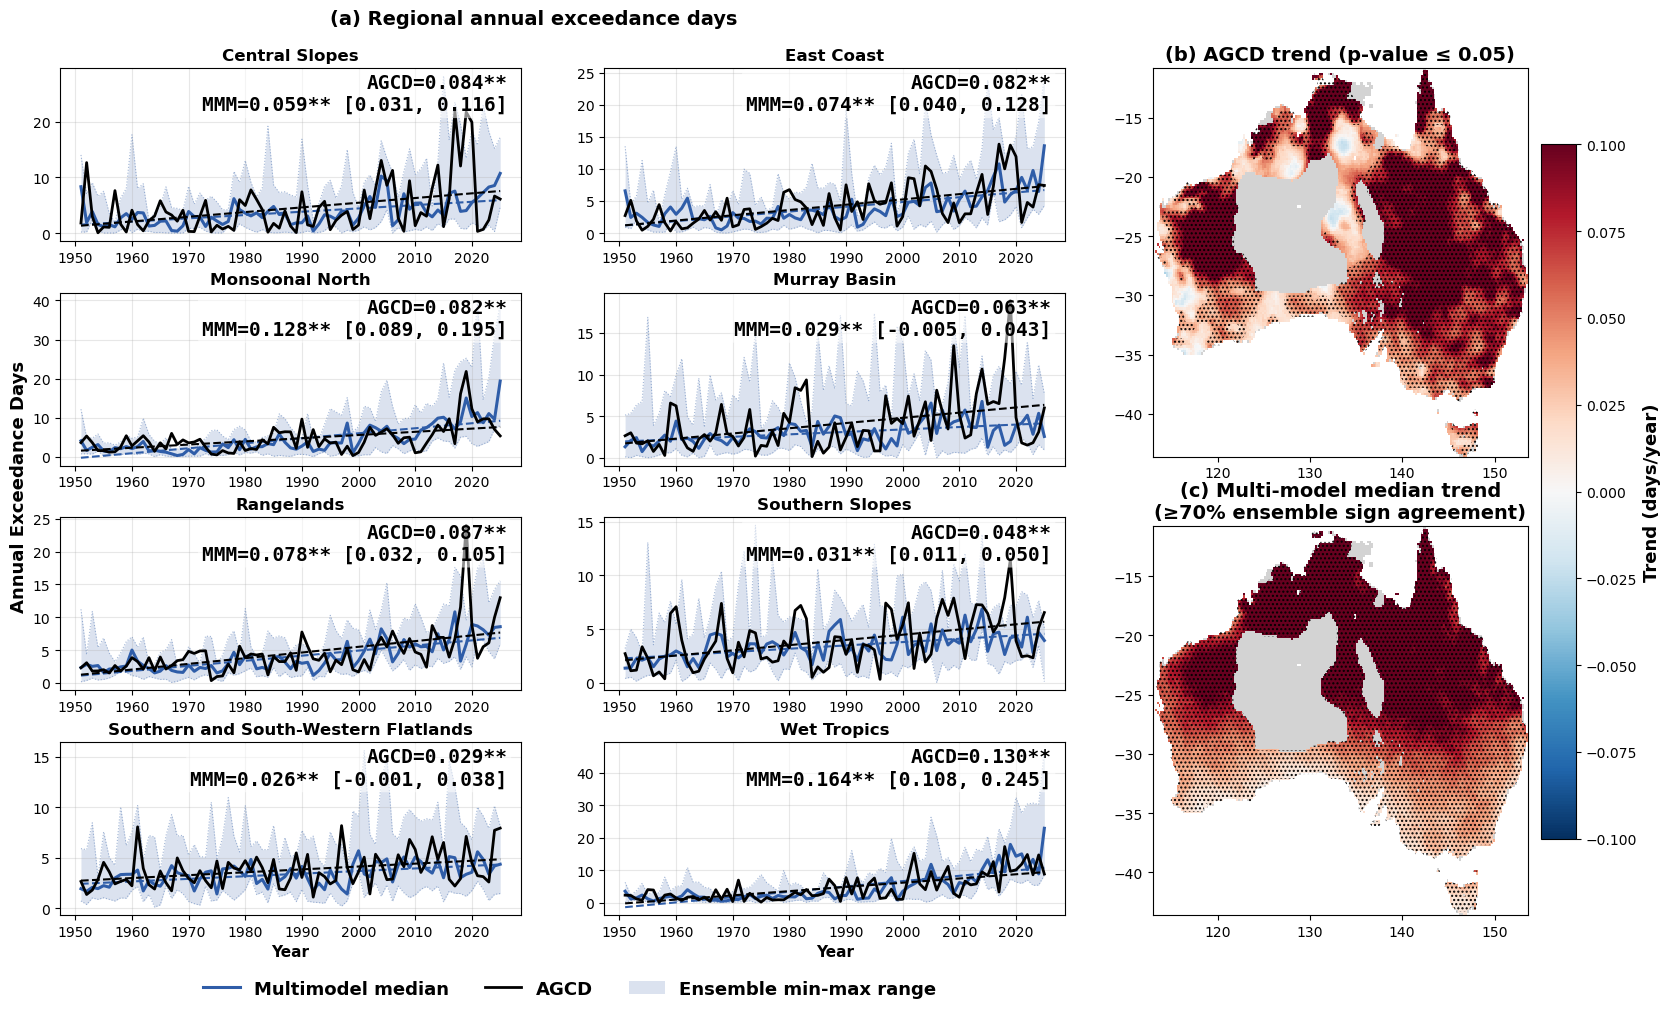

In [3]:
# ============================================================
# 5.5 COMBINED VISUALISATION -tas
# LEFT: NRM TIMESERIES (from redesign 5.2 style)
# RIGHT: AGCD + MMM TREND MAPS + exclude 
# 
# ============================================================

import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from itertools import product
from scipy.stats import linregress
from matplotlib.ticker import FormatStrFormatter

# ============================================================
# SETTINGS
# ============================================================

summary_dir = Path(
    "/scratch/dt6/xw9650/tmp/regridded_AGCD/summaries"
)

trend_dir = Path(
    "/scratch/dt6/xw9650/tmp/regridded_AGCD/trend_maps"
)

output_dir = Path(
    "/scratch/dt6/xw9650/tmp/regridded_AGCD"
)

output_dir.mkdir(exist_ok=True)

# ============================================================
# MODELS
# ============================================================

gcms = [
    "ACCESS-ESM1-5",
    "EC-Earth3-Veg",
    "MPI-ESM1-2-HR",
    "NorESM2-MM",
    "UKESM1-0-LL"
]

rcms = [
    "NARCliM2-0-WRF412R3",
    "NARCliM2-0-WRF412R5"
]

# ============================================================
# LOAD LAND MASK
# ============================================================

mask_file = (
    "/scratch/dt6/xw9650/tmp/regridded/"
    "sftlf_AUS-18_ACCESS-ESM1-5_historical_r6i1p1f1_"
    "NSW-Government_NARCliM2-0-WRF412R3_v1-r1_fx.nc"
)

land_mask = xr.open_dataset(mask_file)["sftlf"] > 50

# ============================================================
# Excluded region MASK
# ============================================================
mask_region = xr.open_dataarray('/g/data/w97/mg5624/RF_project/masks/original_awra_awap_mask.nc')

def regrid_mask(mask, target_data):
 
    mask = mask.sortby('lat')
 
    max_lat = mask['lat'].max().values
    min_lat = mask['lat'].min().values
    max_lon = mask['lon'].max().values
    min_lon = mask['lon'].min().values
 
    mask = mask.astype(int)
 
    target_data = target_data.sel(lat=slice(min_lat, max_lat), lon=slice(min_lon, max_lon))
    regridded_mask = mask.interp_like(target_data, method='nearest')
    new_access_mask = regridded_mask.astype(bool)
 
    return new_access_mask


# ============================================================
# TREND FUNCTION
# ============================================================

def compute_trend(years, values):

    mask = np.isfinite(values)

    years = years[mask]
    values = values[mask]

    if len(years) < 3:
        return np.nan, np.nan

    res = linregress(years, values)

    return res.slope, res.pvalue


# ============================================================
# SIGNIFICANCE STARS
# ============================================================

def stars(p):

    if np.isnan(p):
        return ""

    if p < 0.01:
        return "**"

    elif p < 0.05:
        return "*"

    else:
        return ""


# ============================================================
# LOAD AGCD SUMMARY
# ============================================================

agcd_file = summary_dir / "tas_AGCD_summary_1951_2025.parquet"

agcd_df = pd.read_parquet(agcd_file)

# ============================================================
# LOAD MODEL SUMMARIES
# ============================================================

ensemble_data = {}

for gcm, rcm in product(gcms, rcms):

    file = (
        summary_dir /
        f"tas_{gcm}_{rcm}_summary_1951_2025.parquet"
    )

    if not file.exists():

        print(f"Missing:\n{file}")
        continue

    ensemble_data[f"{gcm}_{rcm}"] = (
        pd.read_parquet(file)
    )

# ============================================================
# DETECT NRMS
# ============================================================

nrms = sorted(agcd_df["NRM"].unique())

print("Detected NRMs:")
print(nrms)

# ============================================================
# FIGURE LAYOUT
# ============================================================

fig = plt.figure(
    figsize=(20, 11)
)

gs = fig.add_gridspec(
    2,
    2,
    width_ratios=[2.2, 1],
    height_ratios=[1, 1],
    wspace=0.12,
    hspace=0.18
)

# ============================================================
# LEFT PANEL SUBGRID
# ============================================================

left_gs = gs[:, 0].subgridspec(
    4,
    2,
    wspace=0.18,
    hspace=0.30
)

axes = []

for i in range(len(nrms)):

    row = i // 2
    col = i % 2

    axes.append(
        fig.add_subplot(left_gs[row, col])
    )

# ============================================================
# RIGHT MAP PANELS
# ============================================================

ax_agcd = fig.add_subplot(gs[0, 1])
ax_mmm = fig.add_subplot(gs[1, 1])

# ============================================================
# STORAGE
# ============================================================

trend_rows = []

# ============================================================
# MAIN LOOP
# ============================================================

for i, (ax, nrm) in enumerate(zip(axes, nrms)):

    ensemble_dfs = []

    # ========================================================
    # COLLECT ENSEMBLE MEMBERS
    # ========================================================

    for member_name, df in ensemble_data.items():

        df_nrm = df[
            df["NRM"] == nrm
        ][[
            "year",
            "annual_exceedance_days"
        ]].copy()

        if df_nrm.empty:
            continue

        df_nrm.rename(
            columns={
                "annual_exceedance_days": member_name
            },
            inplace=True
        )

        ensemble_dfs.append(
            df_nrm.set_index("year")
        )

    if not ensemble_dfs:
        continue

    # ========================================================
    # CREATE ENSEMBLE
    # ========================================================

    df_ensemble = pd.concat(
        ensemble_dfs,
        axis=1
    )

    years = df_ensemble.index.values

    # ========================================================
    # ENSEMBLE STATISTICS
    # ========================================================

    ensemble_median = (
        df_ensemble.median(axis=1)
    )

    ensemble_min = (
        df_ensemble.min(axis=1)
    )

    ensemble_max = (
        df_ensemble.max(axis=1)
    )

    # ========================================================
    # ENSEMBLE MIN-MAX SPREAD
    # ========================================================

    ax.fill_between(
        years,
        ensemble_min,
        ensemble_max,
        color="#4C72B0",
        alpha=0.20,
        linewidth=0,
        zorder=1
    )

    # OPTIONAL:
    # show min/max boundaries more clearly

    ax.plot(
        years,
        ensemble_min,
        color="#4C72B0",
        linewidth=0.8,
        alpha=0.5,
        linestyle=":"
    )

    ax.plot(
        years,
        ensemble_max,
        color="#4C72B0",
        linewidth=0.8,
        alpha=0.5,
        linestyle=":"
    )

    # ========================================================
    # MULTIMODEL MEDIAN
    # ========================================================

    ax.plot(
        years,
        ensemble_median,
        color="#2F5DA8",
        linewidth=2.2,
        label="Multimodel median",
        zorder=3
    )

    # ========================================================
    # MODEL TRENDS
    # ========================================================

    ensemble_slopes = []

    for col in df_ensemble.columns:

        slope_i, p_i = compute_trend(
            years,
            df_ensemble[col].values
        )

        ensemble_slopes.append(slope_i)

        trend_rows.append({
            "NRM": nrm,
            "Source": col,
            "Slope": slope_i,
            "p_value": p_i
        })

    mod_slope, mod_p = compute_trend(
        years,
        ensemble_median.values
    )

    ens_min = np.nanmin(ensemble_slopes)
    ens_max = np.nanmax(ensemble_slopes)

    trend_rows.append({
        "NRM": nrm,
        "Source": "Multimodel median",
        "Slope": mod_slope,
        "p_value": mod_p
    })

    # ========================================================
    # MULTIMODEL TREND LINE
    # ========================================================

    if np.isfinite(mod_slope):

        fit_mod = (
            mod_slope * years
            + np.mean(
                ensemble_median
                - mod_slope * years
            )
        )

        ax.plot(
            years,
            fit_mod,
            color="#2F5DA8",
            linestyle="--",
            linewidth=1.5,
            zorder=4
        )

    # ========================================================
    # AGCD
    # ========================================================

    df_agcd = agcd_df[
        agcd_df["NRM"] == nrm
    ]

    agcd_slope = np.nan
    agcd_p = np.nan

    if not df_agcd.empty:

        ax.plot(
            df_agcd["year"],
            df_agcd["annual_exceedance_days"],
            color="black",
            linewidth=2,
            label="AGCD",
            zorder=5
        )

        x_agcd = df_agcd["year"].values

        y_agcd = df_agcd[
            "annual_exceedance_days"
        ].values

        agcd_slope, agcd_p = compute_trend(
            x_agcd,
            y_agcd
        )

        trend_rows.append({
            "NRM": nrm,
            "Source": "AGCD",
            "Slope": agcd_slope,
            "p_value": agcd_p
        })

        if np.isfinite(agcd_slope):

            fit_agcd = (
                agcd_slope * x_agcd
                + np.mean(
                    y_agcd
                    - agcd_slope * x_agcd
                )
            )

            ax.plot(
                x_agcd,
                fit_agcd,
                color="black",
                linestyle="--",
                linewidth=1.5,
                zorder=6
            )

    # ========================================================
    # PANEL TEXT
    # ========================================================

    text_str = (
        f"AGCD={agcd_slope:.3f}{stars(agcd_p)}\n"
        f"MMM={mod_slope:.3f}{stars(mod_p)} "
        f"[{ens_min:.3f}, {ens_max:.3f}]"
    )


    ax.text(
        0.97,
        0.97,
        text_str,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=14,
        fontweight='bold',
        family="monospace",
        linespacing=1.2,
        bbox=dict(
            boxstyle="round,pad=0.2",
            facecolor="white",
            alpha=0.55,
            edgecolor="none"
        ),
        zorder=10
    )
    # ========================================================
    # PANEL STYLE
    # ========================================================

    ax.set_title(
        nrm,
        fontsize=12,
        fontweight="bold"
    )

    row = i // 2

    if row == 3:

        ax.set_xlabel(
            "Year",
            fontsize=11,
            fontweight="bold"
        )

    else:

        ax.set_xlabel("")

    ax.set_ylabel("")

    ax.yaxis.set_major_formatter(
        FormatStrFormatter("%d")
    )

    ax.tick_params(
        axis="both",
        labelsize=10
    )

    ax.grid(
        alpha=0.3
    )

# ============================================================
# GLOBAL Y LABEL
# ============================================================

fig.text(
    0.1,
    0.5,
    "Annual Exceedance Days",
    va="center",
    rotation="vertical",
    fontsize=13,
    fontweight="bold"
)

# ============================================================
# LOAD TREND MAPS
# ============================================================

agcd_ds = xr.open_dataset(
    trend_dir / "tas_AGCD_trend_1951_2025.nc"
)

mmm_ds = xr.open_dataset(
    trend_dir / "tas_MMM_trend_1951_2025.nc"
)

# ============================================================
# ALIGN MASK
# ============================================================

agcd_ds, land_mask_aligned = xr.align(
    agcd_ds,
    land_mask,
    join="inner"
)

mmm_ds, land_mask_aligned = xr.align(
    mmm_ds,
    land_mask,
    join="inner"
)

agcd_land = agcd_ds.where(
    land_mask_aligned
)
#overlay with regions removing limited stations 
agcd_land_mask = regrid_mask(mask_region, agcd_land)
agcd_land_masked = agcd_land.where(agcd_land_mask)
    


mmm_land = mmm_ds.where(
    land_mask_aligned
)
#overlay with regions removing limited stations 
mmm_land_mask = regrid_mask(mask_region, mmm_land)
mmm_land_masked = mmm_land.where(mmm_land_mask)
    
# ============================================================
# PLOT MAPS
# ============================================================

vmin = -0.1
vmax = 0.1

# ============================================================
# CREATE EXCLUDED LAND MASK
# ============================================================

# valid region mask after regridding
# True  = keep
# False = excluded

excluded_agcd = (
    land_mask_aligned &
    (~agcd_land_mask)
)

excluded_mmm = (
    land_mask_aligned &
    (~mmm_land_mask)
)

# ============================================================
# LIGHT GRAY COLORMAP
# ============================================================

from matplotlib.colors import ListedColormap

gray_cmap = ListedColormap(["lightgray"])

# ============================================================
# PLOT EXCLUDED LAND FIRST
# ============================================================

xr.where(
    excluded_agcd,
    1,
    np.nan
).plot(
    ax=ax_agcd,
    cmap=gray_cmap,
    add_colorbar=False
)

xr.where(
    excluded_mmm,
    1,
    np.nan
).plot(
    ax=ax_mmm,
    cmap=gray_cmap,
    add_colorbar=False
)

# ============================================================
# OVERLAY ACTUAL TREND DATA
# ============================================================

agcd_plot = agcd_land_masked.trend.plot(
    ax=ax_agcd,
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False
)

# ============================================================
# AGCD SIGNIFICANCE STIPPLING (p <= 0.05)
# ============================================================

if "p_value" in agcd_land_masked:

    sig = agcd_land_masked["p_value"] <= 0.05

    step = 3  # adjust density (2–5 usually works well)

    sig_sparse = sig[::step, ::step]

    ax_agcd.contourf(
        agcd_land_masked.lon[::step],
        agcd_land_masked.lat[::step],
        sig_sparse.astype(int),
        levels=[0.5, 1],
        colors="none",
        hatches=["...."],
        alpha=0
        # transform=agcd_plot.axes.get_transform("data")  # optional safety
    )
    

mmm_plot = mmm_land_masked.MMM_trend.plot(
    ax=ax_mmm,
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False
)
# ============================================================
# REMOVE AXIS LABELS (RIGHT PANELS)
# ============================================================

for ax in [ax_agcd, ax_mmm]:
    ax.set_xlabel("")
    ax.set_ylabel("")
    # ax.tick_params(
    #     axis="both",
    #     which="both",
    #     length=3,      # removes tick marks
    #     labelbottom=False,
    #     labelleft=False
    # )
# # ============================================================
# # SIGN AGREEMENT STIPPLING
# # ============================================================

# if "sign_agreement" in mmm_land:

#     sig = mmm_land["sign_agreement"] >= 0.7

#     yy, xx = np.where(sig.values)

#     # reduced density for visibility

#     step = 10

#     yy = yy[::step]
#     xx = xx[::step]

#     ax_mmm.scatter(
#         mmm_land.lon.values[xx],
#         mmm_land.lat.values[yy],
#         s=0.7,
#         color="black",
#         alpha=0.28
#     )


# ============================================================
# HATCHING (70% AGREEMENT)
# ============================================================

if "sign_agreement" in mmm_land_masked:

    sig = mmm_land_masked["sign_agreement"] >= 0.7

    step = 2  # try 2, 3, 4, 5 depending on resolution

    sig_sparse = sig[::step, ::step]

    ax_mmm.contourf(
        mmm_land_masked.lon[::step],
        mmm_land_masked.lat[::step],
        sig_sparse.astype(int),
        levels=[0.5, 1],
        colors="none",
        hatches=["...."],
        alpha=0
    )
    
# ============================================================
# MAP TITLES
# ============================================================

ax_agcd.set_title(
    "(b) AGCD trend (p-value ≤ 0.05)",
    fontsize=14,
    fontweight="bold"
)

ax_mmm.set_title(
    "(c) Multi-model median trend\n"
    "(≥70% ensemble sign agreement)",
    fontsize=14,
    fontweight="bold"
)

# ============================================================
# COLORBAR
# ============================================================

cbar = fig.colorbar(
    agcd_plot,
    ax=[ax_agcd, ax_mmm],
    shrink=0.82,
    pad=0.03
)

cbar.set_label(
    "Trend (days/year)",
    fontsize=13,
    fontweight="bold"
)

# ============================================================
# PANEL LABEL
# ============================================================

fig.text(
    0.26,
    0.92,
    "(a) Regional annual exceedance days",
    fontsize=14,
    fontweight="bold"
)

# ============================================================
# FIGURE LEGEND
# ============================================================

legend_handles = [

    plt.Line2D(
        [0], [0],
        color="#2F5DA8",
        linewidth=2.2
    ),

    plt.Line2D(
        [0], [0],
        color="black",
        linewidth=2
    ),

    plt.Rectangle(
        (0, 0),
        1,
        1,
        facecolor="#4C72B0",
        alpha=0.20
    )
]

# fig.legend(
#     legend_handles,
#     [
#         "Multimodel median",
#         "AGCD",
#         "Ensemble min-max range"
#     ],
#     loc="lower center",
#     ncol=3,
#     fontsize=11,
#     frameon=False
# )
# ============================================================
# FIGURE LEGEND (LEFT PANEL ONLY)--CHANGE1
# ============================================================

# Get bounding box of left panel group
left_bbox = gs[:, 0].get_position(fig)

legend_handles = [

    plt.Line2D([0], [0], color="#2F5DA8", linewidth=2.2),
    plt.Line2D([0], [0], color="black", linewidth=2),
    plt.Rectangle((0, 0), 1, 1, facecolor="#4C72B0", alpha=0.20)

]

legend=fig.legend(
    legend_handles,
    [
        "Multimodel median",
        "AGCD",
        "Ensemble min-max range"
    ],
    loc="lower center",

    bbox_to_anchor=(0.38, 0.02),  # 👈 move into left panel bottom
    ncol=3,
    fontsize=13, #increase font size (CHANGE3),
    frameon=False
)

for text in legend.get_texts():
    text.set_fontweight("bold")

# ============================================================
# SAVE TREND TABLE
# ============================================================

trend_df = pd.DataFrame(trend_rows)

trend_df["Slope"] = (
    trend_df["Slope"]
    .astype(float)
    .round(4)
)

trend_df["p_value"] = (
    trend_df["p_value"]
    .astype(float)
    .round(4)
)

trend_df["Slope_sig"] = (
    trend_df["Slope"].astype(str)
    + trend_df["p_value"].apply(stars)
)

trend_csv = (
    output_dir /
    "tas_annual_exceedance_trends_1951_2025.csv"
)

trend_xlsx = (
    output_dir /
    "tas_annual_exceedance_trends_1951_2025.xlsx"
)

trend_df.to_csv(
    trend_csv,
    index=False
)

trend_df.to_excel(
    trend_xlsx,
    index=False
)

print(f"Saved trend table:\n{trend_csv}")

# ============================================================
# SAVE FIGURE
# ============================================================

plt.tight_layout(
    rect=[0.05, 0.04, 1, 0.95]
)

fig_file = (
    output_dir /
    "tas_combined_timeseries_maps_1951_2025.png"
)

fig.savefig(
    fig_file,
    dpi=300,
    bbox_inches="tight"
)

print(f"Saved figure:\n{fig_file}")

plt.show()

In [29]:
# redesign 6.1--pr
# ============================================================
# COMPUTE ANNUAL HURS EXCEEDANCE SUMMARIES
# DASK-OPTIMISED VERSION
# ============================================================

from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import regionmask

from dask import delayed, compute
from dask.distributed import Client

# ============================================================
# DASK CLIENT
# ============================================================

client = Client(
    n_workers=8,
    threads_per_worker=1,
    memory_limit="8GB"
)

print(client)

# ============================================================
# SETTINGS
# ============================================================

agcd_file = (
    "/scratch/dt6/xw9650/tmp/regridded_AGCD/"
    "precip_univ_exceed_1951_2025.nc"
)

model_template = (
    "/scratch/dt6/xw9650/tmp/regridded_AGCD/exceedance_NARCliM/"
    "pr_{gcm}_{rcm}_ssp370_univ_exceed_1951_2025.nc"
)

mask_shapefile = (
    "/scratch/dt6/xw9650/tmp/reference_data/"
    "NRM_clusters/NRM_clusters.shp"
)

output_dir = Path(
    "/scratch/dt6/xw9650/tmp/regridded_AGCD"
)

summary_dir = output_dir / "summaries"

output_dir.mkdir(exist_ok=True)

summary_dir.mkdir(exist_ok=True)

mask_nc = output_dir / "nrm_mask.nc"

gcms = [
    "ACCESS-ESM1-5",
    "EC-Earth3-Veg",
    "MPI-ESM1-2-HR",
    "NorESM2-MM",
    "UKESM1-0-LL"
]

rcms = [
    "NARCliM2-0-WRF412R3",
    "NARCliM2-0-WRF412R5"
]

# ============================================================
# CREATE REGION MASK ONCE
# ============================================================

def create_nrm_mask(
    sample_file,
    shapefile,
    out_file
):

    print("Creating NRM mask...")

    ds = xr.open_dataset(sample_file)

    gdf = (
        gpd.read_file(shapefile)
        .to_crs("EPSG:4326")
    )

    gdf = gdf[
        gdf.geometry.notnull()
    ]

    regions = regionmask.Regions(
        outlines=list(gdf.geometry),
        names=gdf["label"].tolist(),
        numbers=list(range(len(gdf)))
    )

    mask = regions.mask(
        ds.lon,
        ds.lat
    )

    mask.name = "nrm_mask"

    mask.to_netcdf(out_file)

    print(f"Saved mask:\n{out_file}")

# ============================================================
# CREATE MASK IF MISSING
# ============================================================

if not mask_nc.exists():

    create_nrm_mask(
        agcd_file,
        mask_shapefile,
        mask_nc
    )

# ============================================================
# LOAD MASK
# ============================================================

mask = xr.open_dataarray(mask_nc)

# ============================================================
# REGION NAMES
# ============================================================

gdf_regions = (
    gpd.read_file(mask_shapefile)
    .to_crs("EPSG:4326")
)

region_names = {
    i: name
    for i, name in enumerate(
        gdf_regions["label"].tolist()
    )
}

# ============================================================
# SUMMARY FUNCTION
# ============================================================

def summarise_annual_exceedance(
    nc_file,
    out_file,
    source_name
):

    print(f"\nProcessing:\n{nc_file}")

    ds = xr.open_dataset(
        nc_file,
        chunks={"time": 365}
    )

    # ========================================================
    # AUTO-DETECT VARIABLE
    # ========================================================

    var_name = list(ds.data_vars)[0]

    da = ds[var_name]

    # ========================================================
    # CONVERT BOOLEAN TO INTEGER
    # ========================================================

    if da.dtype == bool:

        da = da.astype("int16")

    # ========================================================
    # ANNUAL SUM
    # ========================================================

    annual = (
        da
        .resample(time="YE")
        .sum(dim="time")
    )

    # ========================================================
    # REGION IDS
    # ========================================================

    region_ids = np.unique(
        mask.values[
            np.isfinite(mask.values)
        ]
    ).astype(int)

    all_rows = []

    # ========================================================
    # LOOP REGIONS
    # ========================================================

    for region_id in region_ids:

        regional = (
            annual
            .where(mask == region_id)
            .mean(dim=["lat", "lon"])
        )

        regional = regional.compute()

        years = regional["time.year"].values

        values = regional.values

        rows = pd.DataFrame({
            "NRM": region_names[region_id],
            "year": years.astype(int),
            "annual_exceedance_days": values.astype(float),
            "Source": source_name
        })

        all_rows.append(rows)

    # ========================================================
    # CONCATENATE
    # ========================================================

    df = pd.concat(
        all_rows,
        ignore_index=True
    )

    # ========================================================
    # SAVE
    # ========================================================

    df.to_parquet(out_file)

    print(f"Saved:\n{out_file}")

    return out_file

# ============================================================
# CREATE TASKS
# ============================================================

tasks = []

# ============================================================
#AGCD TASK
# ============================================================

agcd_out = (
    summary_dir /
    "pr_AGCD_summary_1951_2025.parquet"
)

tasks.append(
    delayed(
        summarise_annual_exceedance
    )(
        agcd_file,
        agcd_out,
        "AGCD"
    )
)

# ============================================================
# MODEL TASKS
# ============================================================

for gcm, rcm in product(gcms, rcms):

    model_file = model_template.format(
        gcm=gcm,
        rcm=rcm
    )

    if not Path(model_file).exists():

        print(f"Missing:\n{model_file}")
        continue

    out_file = (
        summary_dir /
        f"pr_{gcm}_{rcm}_summary_1951_2025.parquet"
    )

    source_name = f"{gcm}_{rcm}"

    tasks.append(
        delayed(
            summarise_annual_exceedance
        )(
            model_file,
            out_file,
            source_name
        )
    )

# ============================================================
# RUN TASKS
# ============================================================

results = compute(*tasks)

print("\nFinished summaries:")

for r in results:
    print(r)

# ============================================================
# CLOSE CLIENT
# ============================================================

client.close()

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 34225 instead
  warnings.warn(


<Client: 'tcp://127.0.0.1:40009' processes=8 threads=8, memory=59.60 GiB>

Finished summaries:
/scratch/dt6/xw9650/tmp/regridded_AGCD/summaries/pr_AGCD_summary_1951_2025.parquet
/scratch/dt6/xw9650/tmp/regridded_AGCD/summaries/pr_ACCESS-ESM1-5_NARCliM2-0-WRF412R3_summary_1951_2025.parquet
/scratch/dt6/xw9650/tmp/regridded_AGCD/summaries/pr_ACCESS-ESM1-5_NARCliM2-0-WRF412R5_summary_1951_2025.parquet
/scratch/dt6/xw9650/tmp/regridded_AGCD/summaries/pr_EC-Earth3-Veg_NARCliM2-0-WRF412R3_summary_1951_2025.parquet
/scratch/dt6/xw9650/tmp/regridded_AGCD/summaries/pr_EC-Earth3-Veg_NARCliM2-0-WRF412R5_summary_1951_2025.parquet
/scratch/dt6/xw9650/tmp/regridded_AGCD/summaries/pr_MPI-ESM1-2-HR_NARCliM2-0-WRF412R3_summary_1951_2025.parquet
/scratch/dt6/xw9650/tmp/regridded_AGCD/summaries/pr_MPI-ESM1-2-HR_NARCliM2-0-WRF412R5_summary_1951_2025.parquet
/scratch/dt6/xw9650/tmp/regridded_AGCD/summaries/pr_NorESM2-MM_NARCliM2-0-WRF412R3_summary_1951_2025.parquet
/scratch/dt6/xw9650/tmp/regridded_AGCD/su

2026-07-03 01:16:49,425 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2026-07-03 01:16:49,430 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2026-07-03 01:16:49,437 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2026-07-03 01:16:49,437 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2026-07-03 01:16:49,439 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2026-07-03 01:16:49,440 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2026-07-03 01:16:49,442 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2026-07-03 01:16:49,443 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing


In [3]:
# redesign 6.2 -create gridcell trends data --pr

# ============================================================
# COMPUTE GRIDCELL TRENDS FROM EXCEEDANCE DATA
# VECTORISED + DASK OPTIMISED
# ============================================================

from itertools import product
from pathlib import Path

import numpy as np
import xarray as xr
from dask import delayed, compute
from dask.distributed import Client
from scipy.stats import linregress

# ============================================================
# DASK CLIENT
# ============================================================

client = Client(
    n_workers=8,
    threads_per_worker=1,
    memory_limit="8GB"
)

print(client)

# ============================================================
# SETTINGS
# ============================================================

START_YEAR = 1951
END_YEAR = 2025

obs_file = (
    "/scratch/dt6/xw9650/tmp/regridded_AGCD/"
    "precip_univ_exceed.nc"
)

model_template = (
    "/scratch/dt6/xw9650/tmp/regridded_AGCD/exceedance_NARCliM/"
    "pr_{gcm}_{rcm}_ssp370_univ_exceed_1951_2025.nc"
)

output_dir = Path(
    "/scratch/dt6/xw9650/tmp/regridded_AGCD/trend_maps"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

gcms = [
    "ACCESS-ESM1-5",
    "EC-Earth3-Veg",
    "MPI-ESM1-2-HR",
    "NorESM2-MM",
    "UKESM1-0-LL"
]

rcms = [
    "NARCliM2-0-WRF412R3",
    "NARCliM2-0-WRF412R5"
]

# ============================================================
# TREND FUNCTION
# ============================================================

def compute_gridcell_trend(nc_file, out_file):

    print(f"\nProcessing:\n{nc_file}")

    # --------------------------------------------------------
    # OPEN
    # --------------------------------------------------------

    ds = xr.open_dataset(
        nc_file,
        chunks={"lat": 10, "lon": 10}
    )

    var_name = list(ds.data_vars)[0]
    da = ds[var_name]

    # ============================================================
    # FILTER TIME (CRITICAL FIX)
    # ============================================================

    da = da.where(
        (da.time.dt.year >= START_YEAR) &
        (da.time.dt.year <= END_YEAR),
        drop=True
    )

    # --------------------------------------------------------
    # BOOLEAN -> INTEGER
    # --------------------------------------------------------

    if da.dtype == bool:
        da = da.astype("int16")

    # --------------------------------------------------------
    # ANNUAL EXCEEDANCE DAYS
    # --------------------------------------------------------

    annual = (
        da
        .resample(time="YE")
        .sum(dim="time")
    )

    # --------------------------------------------------------
    # YEAR COORDINATE
    # --------------------------------------------------------

    annual = annual.assign_coords(
        year=("time", annual["time.year"].values)
    )

    # --------------------------------------------------------
    # TREND (PIXEL-WISE)
    # --------------------------------------------------------

    trend_ds = annual.polyfit(
        dim="year",
        deg=1,
        skipna=True
    )

    slope = trend_ds.polyfit_coefficients.sel(degree=1)
    slope.name = "trend"

    slope.attrs["description"] = (
        f"Trend in annual exceedance days "
        f"(days/year), {START_YEAR}-{END_YEAR}"
    )

    # --------------------------------------------------------
    # SAVE
    # --------------------------------------------------------

    slope.to_netcdf(out_file)

    print(f"Saved:\n{out_file}")

    return out_file
# ============================================================
# TREND FUNCTION (UPDATED to include p-value)
# ============================================================

def compute_gridcell_trend_with_pvalue(nc_file, out_file):

    print(f"\nProcessing:\n{nc_file}")

    ds = xr.open_dataset(
        nc_file,
        chunks={"lat": 10, "lon": 10}
    )

    var_name = list(ds.data_vars)[0]
    da = ds[var_name]

    # --------------------------------------------------------
    # TIME FILTER
    # --------------------------------------------------------

    da = da.where(
        (da.time.dt.year >= START_YEAR) &
        (da.time.dt.year <= END_YEAR),
        drop=True
    )

    if da.dtype == bool:
        da = da.astype("int16")

    # --------------------------------------------------------
    # ANNUAL SUM
    # --------------------------------------------------------

    annual = da.resample(time="YE").sum(dim="time")

    years = annual["time.year"].values

    # ========================================================
    # MINIMAL CHANGE: ADD SIGNIFICANCE VIA LINREGRESS
    # ========================================================

    def _trend(y):

        if np.all(np.isnan(y)):
            return np.array([np.nan, np.nan])

        slope, intercept, r, p, stderr = linregress(years, y)

        return np.array([slope, p])   # slope + p-value

    result = xr.apply_ufunc(
        _trend,
        annual,
        input_core_dims=[["time"]],
        output_core_dims=[["stat"]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
        output_sizes={"stat": 2}
    )

    slope = result.isel(stat=0)
    pval = result.isel(stat=1)

    slope.name = "trend"
    pval.name = "p_value"

    slope.attrs["description"] = (
        f"Trend in annual exceedance (days/year), "
        f"{START_YEAR}-{END_YEAR}"
    )

    pval.attrs["description"] = "p-value of linear trend"

    # --------------------------------------------------------
    # SAVE (NOW DATASET INSTEAD OF SINGLE VARIABLE)
    # --------------------------------------------------------

    out_ds = xr.Dataset({
        "trend": slope,
        "p_value": pval
    })

    out_ds.to_netcdf(out_file)

    print(f"Saved:\n{out_file}")

    return out_file

# ============================================================
# TASKS
# ============================================================

tasks = []


# ------------------------------------------------------------
# MODELS
# ------------------------------------------------------------

for gcm, rcm in product(gcms, rcms):

    model_file = model_template.format(
        gcm=gcm,
        rcm=rcm
    )

    if not Path(model_file).exists():
        print(f"Missing:\n{model_file}")
        continue

    out_file = (
        output_dir /
        f"pr_{gcm}_{rcm}_trend_1951_2025.nc"
    )

    tasks.append(
        delayed(compute_gridcell_trend)(
            model_file,
            out_file
        )
    )

# ============================================================
# RUN
# ============================================================

results = compute(*tasks)

print("\nFinished trend calculations:")
print(results)

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 33131 instead
  warnings.warn(


<Client: 'tcp://127.0.0.1:35455' processes=8 threads=8, memory=59.60 GiB>

Finished trend calculations:
(PosixPath('/scratch/dt6/xw9650/tmp/regridded_AGCD/trend_maps/pr_ACCESS-ESM1-5_NARCliM2-0-WRF412R3_trend_1951_2025.nc'), PosixPath('/scratch/dt6/xw9650/tmp/regridded_AGCD/trend_maps/pr_ACCESS-ESM1-5_NARCliM2-0-WRF412R5_trend_1951_2025.nc'), PosixPath('/scratch/dt6/xw9650/tmp/regridded_AGCD/trend_maps/pr_EC-Earth3-Veg_NARCliM2-0-WRF412R3_trend_1951_2025.nc'), PosixPath('/scratch/dt6/xw9650/tmp/regridded_AGCD/trend_maps/pr_EC-Earth3-Veg_NARCliM2-0-WRF412R5_trend_1951_2025.nc'), PosixPath('/scratch/dt6/xw9650/tmp/regridded_AGCD/trend_maps/pr_MPI-ESM1-2-HR_NARCliM2-0-WRF412R3_trend_1951_2025.nc'), PosixPath('/scratch/dt6/xw9650/tmp/regridded_AGCD/trend_maps/pr_MPI-ESM1-2-HR_NARCliM2-0-WRF412R5_trend_1951_2025.nc'), PosixPath('/scratch/dt6/xw9650/tmp/regridded_AGCD/trend_maps/pr_NorESM2-MM_NARCliM2-0-WRF412R3_trend_1951_2025.nc'), PosixPath('/scratch/dt6/xw9650/tmp/regridded_AGCD/trend_ma

In [4]:
#6.2.2 +add sign agreement --pr
# ============================================================
# MULTI-MODEL MEDIAN TREND
# + SIGN AGREEMENT
# ============================================================

import xarray as xr
import numpy as np

from pathlib import Path

# ============================================================
# PATHS
# ============================================================

trend_dir = Path(
    "/scratch/dt6/xw9650/tmp/regridded_AGCD/trend_maps"
)

# ============================================================
# LOAD ALL MODEL TREND FILES
# ============================================================

model_trends = []

model_names = []

for f in trend_dir.glob("pr*_trend_1951_2025.nc"):

    if "AGCD" in f.name:
        continue

    if "MMM" in f.name:
        continue

    da = xr.open_dataarray(f)

    model_trends.append(da)

    model_names.append(f.stem)

print(f"Loaded {len(model_trends)} model trend files")

# ============================================================
# STACK MODELS
# ============================================================

stacked = xr.concat(
    model_trends,
    dim="model"
)

stacked["model"] = model_names

# ============================================================
# MULTI-MODEL MEDIAN
# ============================================================

mmm_trend = stacked.median(dim="model")

mmm_trend.name = "MMM_trend"

# ============================================================
# SIGN AGREEMENT
# ============================================================

# Positive trend models
n_positive = (stacked > 0).sum(dim="model")

# Negative trend models
n_negative = (stacked < 0).sum(dim="model")

# Total valid models
n_total = np.isfinite(stacked).sum(dim="model")

# Maximum agreement
max_agree = xr.ufuncs.maximum(
    n_positive,
    n_negative
)

# Fraction agreeing on sign
sign_agreement = (
    max_agree / n_total
)

sign_agreement.name = "sign_agreement"

sign_agreement.attrs = {
    "description":
        "Fraction of ensemble members agreeing on trend sign"
}

# ============================================================
# STIPPLE MASK
# ============================================================

stippling = sign_agreement >= 0.7

stippling.name = "stippling"

stippling.attrs = {
    "description":
        "True where >=70% of models agree on trend sign"
}

# ============================================================
# CREATE OUTPUT DATASET
# ============================================================

ds_out = xr.Dataset({

    "MMM_trend": mmm_trend,

    "sign_agreement": sign_agreement,

    "stippling": stippling

})

# ============================================================
# ATTRIBUTES
# ============================================================

ds_out["MMM_trend"].attrs = {
    "description":
        "Multimodel median trend (days/year)"
}

# ============================================================
# SAVE
# ============================================================

mmm_out = trend_dir / "pr_MMM_trend_1951_2025.nc"

ds_out.to_netcdf(mmm_out)

print(f"Saved multimodel median trend:\n{mmm_out}")

Loaded 10 model trend files
Saved multimodel median trend:
/scratch/dt6/xw9650/tmp/regridded_AGCD/trend_maps/pr_MMM_trend_1951_2025.nc


Detected NRMs:
['Central Slopes', 'East Coast', 'Monsoonal North', 'Murray Basin', 'Rangelands', 'Southern Slopes', 'Southern and South-Western Flatlands', 'Wet Tropics']
Saved trend table:
/scratch/dt6/xw9650/tmp/regridded_AGCD/pr_annual_exceedance_trends_1951_2025.csv


/jobfs/176809121.gadi-pbs/ipykernel_1934750/1169567208.py:923: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


Saved figure:
/scratch/dt6/xw9650/tmp/regridded_AGCD/pr_combined_timeseries_maps_1951_2025.png


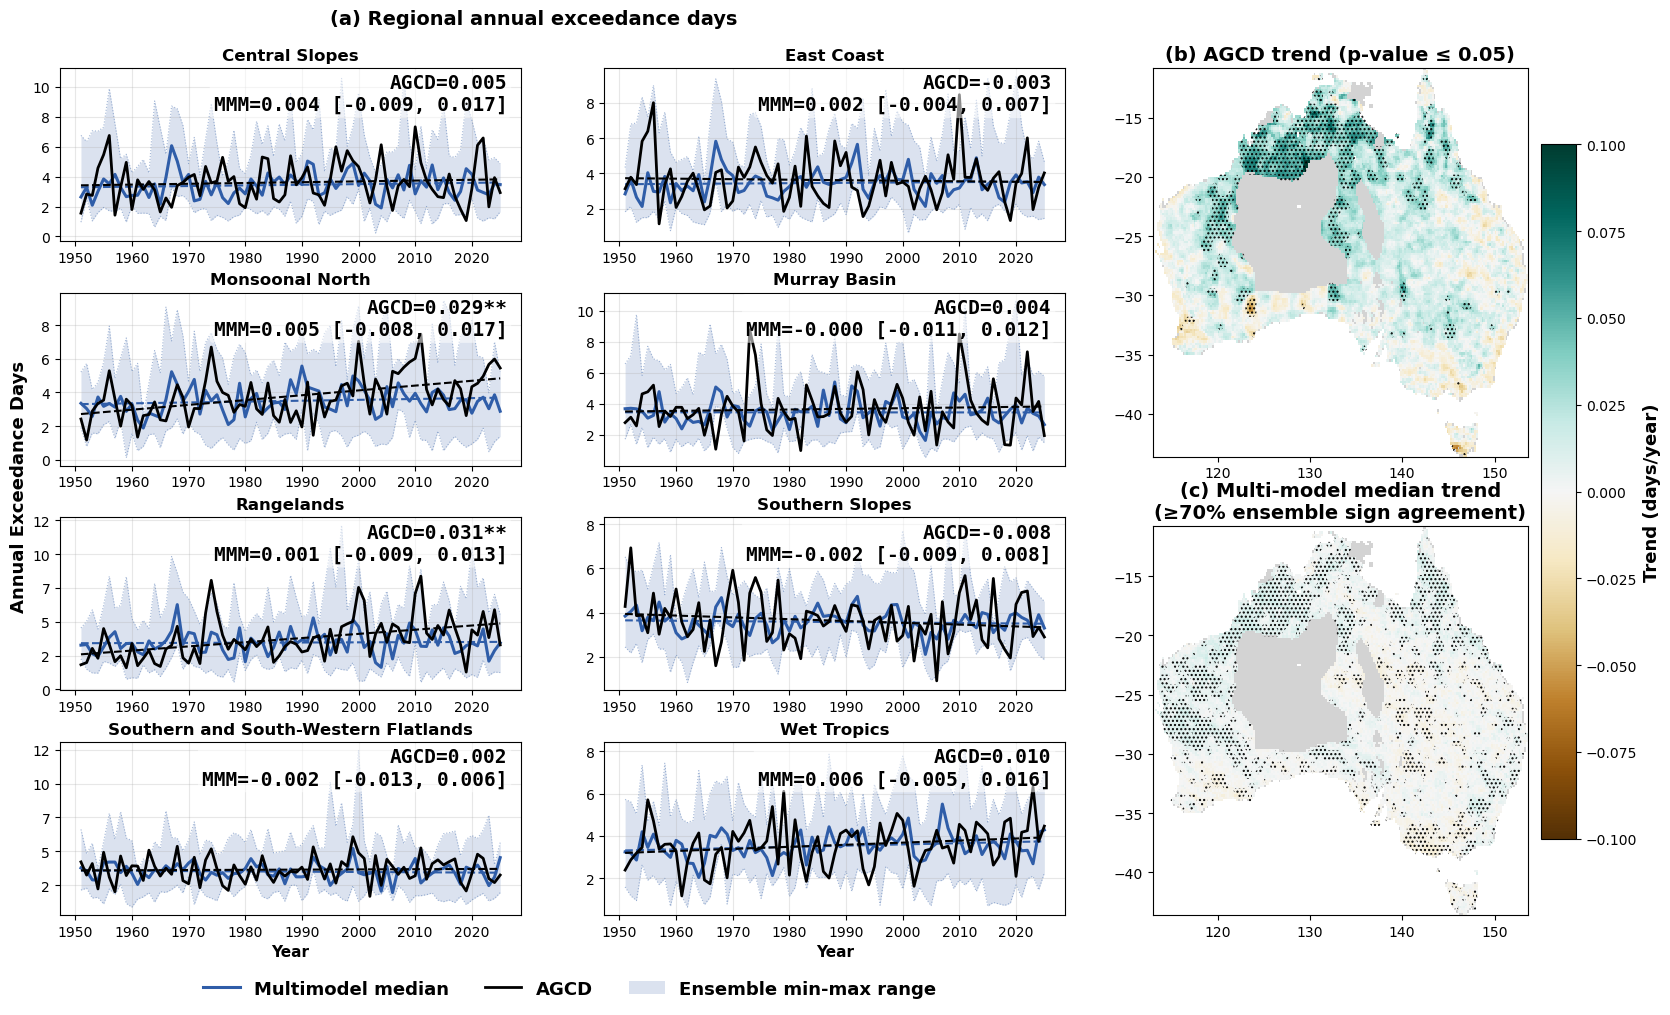

In [4]:
# ============================================================
# 6.5 COMBINED VISUALISATION -pr
# LEFT: NRM TIMESERIES (from redesign 5.2 style)
# RIGHT: AGCD + MMM TREND MAPS + exclude 
# 
# ============================================================

import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from itertools import product
from scipy.stats import linregress
from matplotlib.ticker import FormatStrFormatter

# ============================================================
# SETTINGS
# ============================================================

summary_dir = Path(
    "/scratch/dt6/xw9650/tmp/regridded_AGCD/summaries"
)

trend_dir = Path(
    "/scratch/dt6/xw9650/tmp/regridded_AGCD/trend_maps"
)

output_dir = Path(
    "/scratch/dt6/xw9650/tmp/regridded_AGCD"
)

output_dir.mkdir(exist_ok=True)

# ============================================================
# MODELS
# ============================================================

gcms = [
    "ACCESS-ESM1-5",
    "EC-Earth3-Veg",
    "MPI-ESM1-2-HR",
    "NorESM2-MM",
    "UKESM1-0-LL"
]

rcms = [
    "NARCliM2-0-WRF412R3",
    "NARCliM2-0-WRF412R5"
]

# ============================================================
# LOAD LAND MASK
# ============================================================

mask_file = (
    "/scratch/dt6/xw9650/tmp/regridded/"
    "sftlf_AUS-18_ACCESS-ESM1-5_historical_r6i1p1f1_"
    "NSW-Government_NARCliM2-0-WRF412R3_v1-r1_fx.nc"
)

land_mask = xr.open_dataset(mask_file)["sftlf"] > 50

# ============================================================
# Excluded region MASK
# ============================================================
mask_region = xr.open_dataarray('/g/data/w97/mg5624/RF_project/masks/original_awra_awap_mask.nc')

def regrid_mask(mask, target_data):
 
    mask = mask.sortby('lat')
 
    max_lat = mask['lat'].max().values
    min_lat = mask['lat'].min().values
    max_lon = mask['lon'].max().values
    min_lon = mask['lon'].min().values
 
    mask = mask.astype(int)
 
    target_data = target_data.sel(lat=slice(min_lat, max_lat), lon=slice(min_lon, max_lon))
    regridded_mask = mask.interp_like(target_data, method='nearest')
    new_access_mask = regridded_mask.astype(bool)
 
    return new_access_mask


# ============================================================
# TREND FUNCTION
# ============================================================

def compute_trend(years, values):

    mask = np.isfinite(values)

    years = years[mask]
    values = values[mask]

    if len(years) < 3:
        return np.nan, np.nan

    res = linregress(years, values)

    return res.slope, res.pvalue


# ============================================================
# SIGNIFICANCE STARS
# ============================================================

def stars(p):

    if np.isnan(p):
        return ""

    if p < 0.01:
        return "**"

    elif p < 0.05:
        return "*"

    else:
        return ""


# ============================================================
# LOAD AGCD SUMMARY
# ============================================================

agcd_file = summary_dir / "pr_AGCD_summary_1951_2025.parquet"

agcd_df = pd.read_parquet(agcd_file)

# ============================================================
# LOAD MODEL SUMMARIES
# ============================================================

ensemble_data = {}

for gcm, rcm in product(gcms, rcms):

    file = (
        summary_dir /
        f"pr_{gcm}_{rcm}_summary_1951_2025.parquet"
    )

    if not file.exists():

        print(f"Missing:\n{file}")
        continue

    ensemble_data[f"{gcm}_{rcm}"] = (
        pd.read_parquet(file)
    )

# ============================================================
# DETECT NRMS
# ============================================================

nrms = sorted(agcd_df["NRM"].unique())

print("Detected NRMs:")
print(nrms)

# ============================================================
# FIGURE LAYOUT
# ============================================================

fig = plt.figure(
    figsize=(20, 11)
)

gs = fig.add_gridspec(
    2,
    2,
    width_ratios=[2.2, 1],
    height_ratios=[1, 1],
    wspace=0.12,
    hspace=0.18
)

# ============================================================
# LEFT PANEL SUBGRID
# ============================================================

left_gs = gs[:, 0].subgridspec(
    4,
    2,
    wspace=0.18,
    hspace=0.30
)

axes = []

for i in range(len(nrms)):

    row = i // 2
    col = i % 2

    axes.append(
        fig.add_subplot(left_gs[row, col])
    )

# ============================================================
# RIGHT MAP PANELS
# ============================================================

ax_agcd = fig.add_subplot(gs[0, 1])
ax_mmm = fig.add_subplot(gs[1, 1])

# ============================================================
# STORAGE
# ============================================================

trend_rows = []

# ============================================================
# MAIN LOOP
# ============================================================

for i, (ax, nrm) in enumerate(zip(axes, nrms)):

    ensemble_dfs = []

    # ========================================================
    # COLLECT ENSEMBLE MEMBERS
    # ========================================================

    for member_name, df in ensemble_data.items():

        df_nrm = df[
            df["NRM"] == nrm
        ][[
            "year",
            "annual_exceedance_days"
        ]].copy()

        if df_nrm.empty:
            continue

        df_nrm.rename(
            columns={
                "annual_exceedance_days": member_name
            },
            inplace=True
        )

        ensemble_dfs.append(
            df_nrm.set_index("year")
        )

    if not ensemble_dfs:
        continue

    # ========================================================
    # CREATE ENSEMBLE
    # ========================================================

    df_ensemble = pd.concat(
        ensemble_dfs,
        axis=1
    )

    years = df_ensemble.index.values

    # ========================================================
    # ENSEMBLE STATISTICS
    # ========================================================

    ensemble_median = (
        df_ensemble.median(axis=1)
    )

    ensemble_min = (
        df_ensemble.min(axis=1)
    )

    ensemble_max = (
        df_ensemble.max(axis=1)
    )

    # ========================================================
    # ENSEMBLE MIN-MAX SPREAD
    # ========================================================

    ax.fill_between(
        years,
        ensemble_min,
        ensemble_max,
        color="#4C72B0",
        alpha=0.20,
        linewidth=0,
        zorder=1
    )

    # OPTIONAL:
    # show min/max boundaries more clearly

    ax.plot(
        years,
        ensemble_min,
        color="#4C72B0",
        linewidth=0.8,
        alpha=0.5,
        linestyle=":"
    )

    ax.plot(
        years,
        ensemble_max,
        color="#4C72B0",
        linewidth=0.8,
        alpha=0.5,
        linestyle=":"
    )

    # ========================================================
    # MULTIMODEL MEDIAN
    # ========================================================

    ax.plot(
        years,
        ensemble_median,
        color="#2F5DA8",
        linewidth=2.2,
        label="Multimodel median",
        zorder=3
    )

    # ========================================================
    # MODEL TRENDS
    # ========================================================

    ensemble_slopes = []

    for col in df_ensemble.columns:

        slope_i, p_i = compute_trend(
            years,
            df_ensemble[col].values
        )

        ensemble_slopes.append(slope_i)

        trend_rows.append({
            "NRM": nrm,
            "Source": col,
            "Slope": slope_i,
            "p_value": p_i
        })

    mod_slope, mod_p = compute_trend(
        years,
        ensemble_median.values
    )

    ens_min = np.nanmin(ensemble_slopes)
    ens_max = np.nanmax(ensemble_slopes)

    trend_rows.append({
        "NRM": nrm,
        "Source": "Multimodel median",
        "Slope": mod_slope,
        "p_value": mod_p
    })

    # ========================================================
    # MULTIMODEL TREND LINE
    # ========================================================

    if np.isfinite(mod_slope):

        fit_mod = (
            mod_slope * years
            + np.mean(
                ensemble_median
                - mod_slope * years
            )
        )

        ax.plot(
            years,
            fit_mod,
            color="#2F5DA8",
            linestyle="--",
            linewidth=1.5,
            zorder=4
        )

    # ========================================================
    # AGCD
    # ========================================================

    df_agcd = agcd_df[
        agcd_df["NRM"] == nrm
    ]

    agcd_slope = np.nan
    agcd_p = np.nan

    if not df_agcd.empty:

        ax.plot(
            df_agcd["year"],
            df_agcd["annual_exceedance_days"],
            color="black",
            linewidth=2,
            label="AGCD",
            zorder=5
        )

        x_agcd = df_agcd["year"].values

        y_agcd = df_agcd[
            "annual_exceedance_days"
        ].values

        agcd_slope, agcd_p = compute_trend(
            x_agcd,
            y_agcd
        )

        trend_rows.append({
            "NRM": nrm,
            "Source": "AGCD",
            "Slope": agcd_slope,
            "p_value": agcd_p
        })

        if np.isfinite(agcd_slope):

            fit_agcd = (
                agcd_slope * x_agcd
                + np.mean(
                    y_agcd
                    - agcd_slope * x_agcd
                )
            )

            ax.plot(
                x_agcd,
                fit_agcd,
                color="black",
                linestyle="--",
                linewidth=1.5,
                zorder=6
            )

    # ========================================================
    # PANEL TEXT
    # ========================================================

    text_str = (
        f"AGCD={agcd_slope:.3f}{stars(agcd_p)}\n"
        f"MMM={mod_slope:.3f}{stars(mod_p)} "
        f"[{ens_min:.3f}, {ens_max:.3f}]"
    )

  
    ax.text(
        0.97,
        0.97,
        text_str,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=14,
        fontweight='bold',
        family="monospace",
        linespacing=1.2,
        bbox=dict(
            boxstyle="round,pad=0.2",
            facecolor="white",
            alpha=0.55,
            edgecolor="none"
        ),
        zorder=10
    )
    # ========================================================
    # PANEL STYLE
    # ========================================================

    ax.set_title(
        nrm,
        fontsize=12,
        fontweight="bold"
    )

    row = i // 2

    if row == 3:

        ax.set_xlabel(
            "Year",
            fontsize=11,
            fontweight="bold"
        )

    else:

        ax.set_xlabel("")

    ax.set_ylabel("")

    ax.yaxis.set_major_formatter(
        FormatStrFormatter("%d")
    )

    ax.tick_params(
        axis="both",
        labelsize=10
    )

    ax.grid(
        alpha=0.3
    )

# ============================================================
# GLOBAL Y LABEL
# ============================================================

fig.text(
    0.1,
    0.5,
    "Annual Exceedance Days",
    va="center",
    rotation="vertical",
    fontsize=13,
    fontweight="bold"
)

# ============================================================
# LOAD TREND MAPS
# ============================================================

agcd_ds = xr.open_dataset(
    trend_dir / "pr_AGCD_trend_1951_2025.nc"
)

mmm_ds = xr.open_dataset(
    trend_dir / "pr_MMM_trend_1951_2025.nc"
)

# ============================================================
# ALIGN MASK
# ============================================================

agcd_ds, land_mask_aligned = xr.align(
    agcd_ds,
    land_mask,
    join="inner"
)

mmm_ds, land_mask_aligned = xr.align(
    mmm_ds,
    land_mask,
    join="inner"
)

agcd_land = agcd_ds.where(
    land_mask_aligned
)
#overlay with regions removing limited stations 
agcd_land_mask = regrid_mask(mask_region, agcd_land)
agcd_land_masked = agcd_land.where(agcd_land_mask)
    


mmm_land = mmm_ds.where(
    land_mask_aligned
)
#overlay with regions removing limited stations 
mmm_land_mask = regrid_mask(mask_region, mmm_land)
mmm_land_masked = mmm_land.where(mmm_land_mask)
    
# ============================================================
# PLOT MAPS
# ============================================================

vmin = -0.1
vmax = 0.1

# ============================================================
# CREATE EXCLUDED LAND MASK
# ============================================================

# valid region mask after regridding
# True  = keep
# False = excluded

excluded_agcd = (
    land_mask_aligned &
    (~agcd_land_mask)
)

excluded_mmm = (
    land_mask_aligned &
    (~mmm_land_mask)
)

# ============================================================
# LIGHT GRAY COLORMAP
# ============================================================

from matplotlib.colors import ListedColormap

gray_cmap = ListedColormap(["lightgray"])

# ============================================================
# PLOT EXCLUDED LAND FIRST
# ============================================================

xr.where(
    excluded_agcd,
    1,
    np.nan
).plot(
    ax=ax_agcd,
    cmap=gray_cmap,
    add_colorbar=False
)

xr.where(
    excluded_mmm,
    1,
    np.nan
).plot(
    ax=ax_mmm,
    cmap=gray_cmap,
    add_colorbar=False
)

# ============================================================
# OVERLAY ACTUAL TREND DATA
# ============================================================

agcd_plot = agcd_land_masked.trend.plot(
    ax=ax_agcd,
    cmap="BrBG",
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False
)

# ============================================================
# AGCD SIGNIFICANCE STIPPLING (p <= 0.05)
# ============================================================

if "p_value" in agcd_land_masked:

    sig = agcd_land_masked["p_value"] <= 0.05

    step = 3  # adjust density (2–5 usually works well)

    sig_sparse = sig[::step, ::step]

    ax_agcd.contourf(
        agcd_land_masked.lon[::step],
        agcd_land_masked.lat[::step],
        sig_sparse.astype(int),
        levels=[0.5, 1],
        colors="none",
        hatches=["...."],
        alpha=0
       
    )
    

mmm_plot = mmm_land_masked.MMM_trend.plot(
    ax=ax_mmm,
    cmap="BrBG",
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False
)
# ============================================================
# REMOVE AXIS LABELS (RIGHT PANELS)
# ============================================================

for ax in [ax_agcd, ax_mmm]:
    ax.set_xlabel("")
    ax.set_ylabel("")
 


# ============================================================
# HATCHING (70% AGREEMENT)
# ============================================================

if "sign_agreement" in mmm_land_masked:

    sig = mmm_land_masked["sign_agreement"] >= 0.7

    step = 2  # try 2, 3, 4, 5 depending on resolution

    sig_sparse = sig[::step, ::step]

    ax_mmm.contourf(
        mmm_land_masked.lon[::step],
        mmm_land_masked.lat[::step],
        sig_sparse.astype(int),
        levels=[0.5, 1],
        colors="none",
        hatches=["...."],
        alpha=0
    )
    
# ============================================================
# MAP TITLES
# ============================================================

ax_agcd.set_title(
    "(b) AGCD trend (p-value ≤ 0.05)",
    fontsize=14,
    fontweight="bold"
)

ax_mmm.set_title(
    "(c) Multi-model median trend\n"
    "(≥70% ensemble sign agreement)",
    fontsize=14,
    fontweight="bold"
)

# ============================================================
# COLORBAR
# ============================================================

cbar = fig.colorbar(
    agcd_plot,
    ax=[ax_agcd, ax_mmm],
    shrink=0.82,
    pad=0.03
)

cbar.set_label(
    "Trend (days/year)",
    fontsize=13,
    fontweight="bold"
)

# ============================================================
# PANEL LABEL
# ============================================================

fig.text(
    0.26,
    0.92,
    "(a) Regional annual exceedance days",
    fontsize=14,
    fontweight="bold"
)

# ============================================================
# FIGURE LEGEND
# ============================================================

legend_handles = [

    plt.Line2D(
        [0], [0],
        color="#2F5DA8",
        linewidth=2.2
    ),

    plt.Line2D(
        [0], [0],
        color="black",
        linewidth=2
    ),

    plt.Rectangle(
        (0, 0),
        1,
        1,
        facecolor="#4C72B0",
        alpha=0.20
    )
]

# ============================================================
# FIGURE LEGEND (LEFT PANEL ONLY)--CHANGE1
# ============================================================

# Get bounding box of left panel group
left_bbox = gs[:, 0].get_position(fig)

legend_handles = [

    plt.Line2D([0], [0], color="#2F5DA8", linewidth=2.2),
    plt.Line2D([0], [0], color="black", linewidth=2),
    plt.Rectangle((0, 0), 1, 1, facecolor="#4C72B0", alpha=0.20)

]

legend=fig.legend(
    legend_handles,
    [
        "Multimodel median",
        "AGCD",
        "Ensemble min-max range"
    ],
    loc="lower center",
   
    bbox_to_anchor=(0.38, 0.02),  # 👈 move into left panel bottom
    ncol=3,
    fontsize=13, #increase font size (CHANGE3),
    frameon=False
)

for text in legend.get_texts():
    text.set_fontweight("bold")

# ============================================================
# SAVE TREND TABLE
# ============================================================

trend_df = pd.DataFrame(trend_rows)

trend_df["Slope"] = (
    trend_df["Slope"]
    .astype(float)
    .round(4)
)

trend_df["p_value"] = (
    trend_df["p_value"]
    .astype(float)
    .round(4)
)

trend_df["Slope_sig"] = (
    trend_df["Slope"].astype(str)
    + trend_df["p_value"].apply(stars)
)

trend_csv = (
    output_dir /
    "pr_annual_exceedance_trends_1951_2025.csv"
)

trend_xlsx = (
    output_dir /
    "pr_annual_exceedance_trends_1951_2025.xlsx"
)

trend_df.to_csv(
    trend_csv,
    index=False
)

trend_df.to_excel(
    trend_xlsx,
    index=False
)

print(f"Saved trend table:\n{trend_csv}")

# ============================================================
# SAVE FIGURE
# ============================================================

plt.tight_layout(
    rect=[0.05, 0.04, 1, 0.95]
)

fig_file = (
    output_dir /
    "pr_combined_timeseries_maps_1951_2025.png"
)

fig.savefig(
    fig_file,
    dpi=300,
    bbox_inches="tight"
)

print(f"Saved figure:\n{fig_file}")

plt.show()